# EK381 Exploratory Data Analysis <br> Lab 2: Histograms

### This lab was completed by Giacomo Cappelletto.

Before we get to our dataset, we always need to load the necessary libraries with the "import" command. You'll also  notice that libraries are often imported using an abbreviated name via the "as" command. You can use any shorthand you prefer, but the assignments will stick to commonly-accepted abbreviations.

In [2]:
#Numpy is a package for working with arrays, linear algebra, etc. and stands for "numerical Python".
import numpy as np
#Pandas is a package for working with data frames.
import pandas as pd
#Matplotlib is a plotting library that mimics Matlab conventions.
import matplotlib.pyplot as plt
#Seaborn is a data visualization package.
import seaborn as sns

In the last lab, we used a pandas dataframe to generate statistics and plots for the penguins dataset. In this lab, we will start by building a dataframe from scratch, so we can have a better wunderstanding going forward. The commands below create a simple dataframe with fictional data on whether a given day is sunny or rainy as well as whether the BU bridge has traffic or not.

In [3]:
weatherdf = pd.DataFrame(
    {"Weather": ["sunny", "rainy", "rainy", "sunny", "sunny", "rainy", "sunny", "sunny","rainy"],
     "Bridge Traffic": ["no", "no", "yes", "no", "no", "yes", "no", "yes","yes"]})
weatherdf

,Weather,Bridge Traffic
0,sunny,no
1,rainy,no
2,rainy,yes
3,sunny,no
4,sunny,no
5,rainy,yes
6,sunny,no
7,sunny,yes
8,rainy,yes


How many days are sunny *and* have bridge traffic? This is easy to compute with the `count_values()` command.

In [15]:
weatherdf.value_counts()

Weather  Bridge Traffic
sunny    no                4
rainy    yes               3
         no                1
sunny    yes               1
Name: count, dtype: int64

We can read off the number of occurrences for each possible intersection of events. For instance, 4 days are sunny *and* have no bridge traffic. If we collect a sufficient amount of data, it is often reasonable to use the normalized counts as estimates of the "true" probabilities. We can do this by setting `normalize = True` in the `count_values()` command.

In [5]:
weatherdf.value_counts(normalize=True)

Weather  Bridge Traffic
sunny    no                0.444444
rainy    yes               0.333333
         no                0.111111
sunny    yes               0.111111
Name: proportion, dtype: float64

In our mathematical language, let $A = \{\text{sunny}\}$ and $B = \{\text{yes traffic}\}$. Then, our estimates of the probabilities are $$\hat{\mathbb{P}}[A \cap B] = 1/9,~~\hat{\mathbb{P}}[A^c \cap B] = 3/9, ~~\hat{\mathbb{P}}[A \cap B^c] = 4/9,~~\hat{\mathbb{P}}[A^c \cap B^c] = 1/9 \ .$$ (I used the "hat" symbol on top of $\mathbb{P}$ to remind us these are just estimates, and we might get better estimates of the true values with more data.) Now, let's try to visualize this distribution with a bar chart. In pandas, we can usually just add `.plot()` to our command to get a plot.

<Axes: xlabel='Weather,Bridge Traffic', ylabel='Probability'>

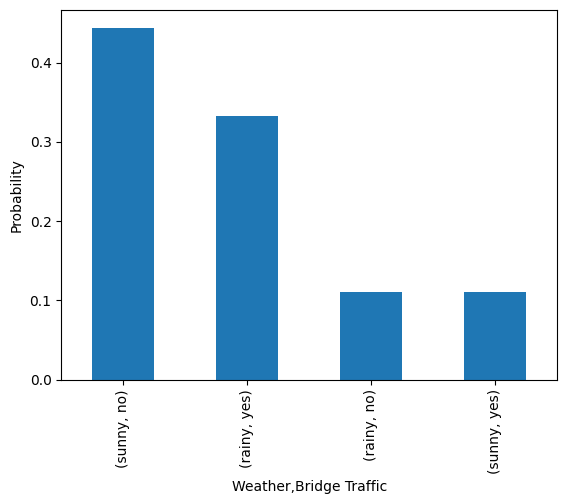

In [6]:
weatherdf.value_counts(normalize=True).plot(kind="bar",ylabel = "Probability")

What if we only want to work with one variable at a time? We can extract a single column from the data frame, either referring to it by its index or by its exact name. An example of each is worked out below for extracting the "Bridge Traffic" column.

**Index:** We can use the `iloc` (index location) command, putting `:` first to indicate "all of the rows" and `1` next to indicate "the second column" since Python starts with index 0.

**Column Name:** We can just put the exact name in quotes (including correct capitalization).

In [7]:
weatherdf.iloc[:,1]

0     no
1     no
2    yes
3     no
4     no
5    yes
6     no
7    yes
8    yes
Name: Bridge Traffic, dtype: str

In [17]:
weatherdf["Bridge Traffic"]

0     no
1     no
2    yes
3     no
4     no
5    yes
6     no
7    yes
8    yes
Name: Bridge Traffic, dtype: str

We can use the commands above to count the values, normalize these counts, and plot the resulting distribution.

In [18]:
weatherdf["Bridge Traffic"].value_counts(normalize = True)

Bridge Traffic
no     0.555556
yes    0.444444
Name: proportion, dtype: float64

<Axes: xlabel='Bridge Traffic', ylabel='Probability'>

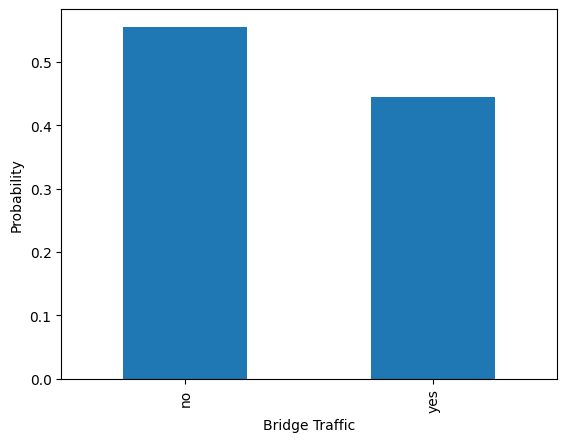

In [10]:
weatherdf["Bridge Traffic"].value_counts(normalize = True).plot(kind = "bar", ylabel = "Probability")

What if we want to estimate and visualize the conditional probabilities? For instance, given that it is sunny, what is the probability there is traffic? (Above, we calculated the probability that it is sunny *and* there is traffic.) The `pd.crosstab()` command will give us a table of the conditional counts (i.e., a contingency table), and takes as inputs the two columns we would like to compare.

In [11]:
pd.crosstab(weatherdf["Bridge Traffic"], weatherdf["Weather"])

Weather,rainy,sunny
Bridge Traffic,,
no,1,4
yes,3,1


We can normalize this by either columns or rows (this is called "index" for crosstab). Below, we've normalized by columns.

In [12]:
pd.crosstab(weatherdf["Bridge Traffic"], weatherdf["Weather"],normalize = "columns")

Weather,rainy,sunny
Bridge Traffic,,
no,0.25,0.8
yes,0.75,0.2


Again, let $A = \{\text{sunny}\}$ and $B = \{\text{yes traffic}\}$. Then, we can think of these values as estimates of the conditional probabilities: $$\hat{\mathbb{P}}[B | A] = 0.2,~~\hat{\mathbb{P}}[B^c | A] = 0.8,~~\hat{\mathbb{P}}[B | A^c] = 0.75,~~\hat{\mathbb{P}}[B^c | A^c] = 0.25 \ .$$   

If we ask pandas to plot this table, we get a grouped bar chart which is a convenient visualization for conditional probabilities.

<Axes: xlabel='Bridge Traffic', ylabel='Probability'>

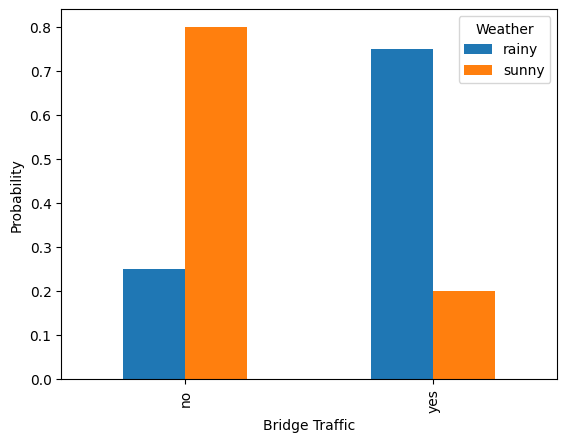

In [13]:
pd.crosstab(weatherdf["Bridge Traffic"], weatherdf["Weather"],normalize = "columns").plot(kind = "bar", ylabel = "Probability")

Throughout the course, we will try to highlight common fallacies that you should try to avoid when applying statistics and analyzing datasets. For a nice visualization of some of the topics we will cover, visit [this link](https://www.geckoboard.com/uploads/data-fallacies-to-avoid.pdf). In this lab, we will focus on [**Simpson's paradox**](https://en.wikipedia.org/wiki/Simpson\%27s_paradox) in which a trend appears across subsets (or groupings) of the data, but then reverses or disappears when we merge the groups. Below, you can see a famous example for kidney stone treatments from *Charig, Clive R., et al. "Comparison of treatment of renal calculi by open surgery, percutaneous nephrolithotomy, and extracorporeal shockwave lithotripsy." Br Med J (Clin Res Ed) 292.6524 (1986): 879-882.*


|Kidney Stone Size | Treatment A | Treatment B |
 --- | --- | --- |
|**Small** | 81 successes out of 87 total (**93\%**) | 234 successes out of 270 total  (87\%)|
| **Large** | 192 successes out of 263 total (**73\%**)| 55 successes out of 80 total (67\%)|
| **Small or Large** | 273 successes out of 350 total (78\%) | 289 successes out of 350 total (**83\%**) |
---

You'll notice that, although Treatment A is more effective for the groups individually, when we combine the data, we get the curious result that Treatment B has a higher success rate overall. In this particular example, this can be understood as follows:
1. Small kidney stones are easier to treat overall.
2. It happened that the Treatment B study included many patients with small kidney stones (270) compared to those with large stones (80), whereas the Treatment A study included many patients with large kidney stones (263) compared to those with small stones (87). Thus, we should expect better outcomes in the Treatment B study since it had an easier population.
3. If we condition on the stone size (sometimes known as the "confounding variable"), we can more clearly see the effectiveness of the treatment.
Overall, the possible fallacy here is that we implicitly assume that each treatment was applied to an equal proportion of small and large stone patients, which is definitely not the case.

Now, let's import our dataset. Following the same method you got successfully working in Lab 1, read in the "entrancesurvey.csv" file as a dataframe called `surveydata`. Recall that CSV (comma-separated values) format is a standard format for tabular data, and can contain both descriptive strings as well as numerical values. CSV files are simple and easy to read/edit directly. You should try opening one with another program, such as a basic text editor or a spreadsheet editor.

In [20]:
surveydata = pd.read_csv("/Users/giacomo/Documents/Engineering/Notes/EK381 - DS and ML/labs/lab2/entrancesurvey.csv") #Put the path to entrancesurvey.csv inside the quotes.

How many rows and columns does the dataframe have?

In [21]:
surveydata.shape

(165, 13)

Next, let's take a quick look at the dataframe. Notice that it indexes the first row with 0, not 1.

In [22]:
#If you want to see the whole dataframe throughout this lab,
#rather than just the first and last 5 rows, uncomment the line immediately below.
#pd.set_option("display.max_rows", None)
surveydata

,Timestamp,"What is your major? (Double majors please pick your ""primary"" major.)",Which of the following do you prefer?,Which of the following best describes your opinion of AI?,Which best describes how you use AI for homework? (Remember this survey is anonymous.),At what age did you get your first smartphone?,"How many countries have you visited? Please write your answer as an integer (e.g., if you've never left the United States, write 1, if you've also been to Canada, write 2, etc.).",Rate the following movies. [Loved it! ],Rate the following movies. [Liked it.],Rate the following movies. [Just OK.],Rate the following movies. [Didn't like it.],Rate the following movies. [Hated it!],Rate the following movies. [Never seen it.]
0,1/16/2026 17:53:28,BME,Pen-and-paper math,"Neutral, and I use it when it helps me.",I use AI to explain concepts and check my answ...,13,4,NaN,Avengers: Endgame,NaN,NaN,NaN,"Avatar: Fire and Ash, Barbie, Dune"
1,1/16/2026 17:53:47,ME,Pen-and-paper math,I like it and I use it wherever possible.,I use AI to explain concepts and check my answ...,13,5,"Frozen, Interstellar, KPop Demon Hunters, My N...",NaN,NaN,NaN,NaN,"Avatar: Fire and Ash, Avengers: Endgame, Barbi..."
2,1/16/2026 17:54:18,ME,Pen-and-paper math,"Neutral, and I use it when it helps me.",I only use AI to check my answers.,11,1,"Avengers: Endgame, Dune, Interstellar, Spider-...","Avatar: Fire and Ash, Barbie, My Neighbor Toto...",Frozen,NaN,NaN,"Get Out, KPop Demon Hunters, Titanic"
3,1/16/2026 17:54:44,ME,Writing reports and making presentations,"Neutral, and I use it when it helps me.",I use AI to explain concepts and check my answ...,13,8,NaN,"Frozen, Spider-Man: Across the Spiderverse, St...",Interstellar,"Barbie, KPop Demon Hunters",NaN,"Avatar: Fire and Ash, Avengers: Endgame, Dune,..."
4,1/16/2026 17:55:15,BME,Writing reports and making presentations,"Neutral, and I use it when it helps me.",I use AI to explain concepts and check my answ...,13,26,Wicked,NaN,Frozen,NaN,NaN,"Avatar: Fire and Ash, Avengers: Endgame, Barbi..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,1/20/2026 15:43:39,ME,Pen-and-paper math,"Neutral, and I use it when it helps me.",I only use AI as a tool in case I do not under...,16,3,"Avatar: Fire and Ash, Dune, Frozen, KPop Demon...","Avengers: Endgame, Barbie, Get Out, Spider-Man...","Interstellar, Titanic",NaN,NaN,Star Wars: The Rise of Skywalker
161,1/20/2026 20:52:26,ME,Pen-and-paper math,I dislike when people use it to outsource basi...,I use AI to explain concepts and check my answ...,11,6,"Avengers: Endgame, Interstellar, KPop Demon Hu...",Barbie,"Frozen, Titanic",NaN,NaN,"Avatar: Fire and Ash, Dune, Get Out, My Neighb..."
162,1/21/2026 9:58:54,CE,Programming algorithms,"Neutral, and I use it when it helps me.",I use AI to explain concepts and check my answ...,11,2,"Interstellar, Titanic","Avengers: Endgame, Frozen, My Neighbor Totoro",NaN,NaN,NaN,"Avatar: Fire and Ash, Barbie, Dune, Get Out, K..."
163,1/21/2026 17:51:16,ME,Pen-and-paper math,I dislike it and I avoid it if I can.,I don't use AI at all.,13,4,"Frozen, Interstellar, My Neighbor Totoro, Star...","Get Out, KPop Demon Hunters","Avengers: Endgame, Barbie, Spider-Man: Across ...",Dune,NaN,"Avatar: Fire and Ash, Superman (2025), Titanic..."


We will limit ourselves to the first five columns in this lab. One way to access these columns is with the `iloc[:,1:6]` command where `iloc` refers to "index location", putting first `:` refers to "all of the rows, and putting `1:6` next refers to columns 1 through 5. (Python indexing is funny like this, ending right before the last element of a requested interval.) **We will set this equal to a new dataframe called `df` that you should use below.** Note that changes to `df` will not impact the original dataframe `surveydata`.

In [23]:
df = surveydata.iloc[:,1:6]
df

,"What is your major? (Double majors please pick your ""primary"" major.)",Which of the following do you prefer?,Which of the following best describes your opinion of AI?,Which best describes how you use AI for homework? (Remember this survey is anonymous.),At what age did you get your first smartphone?
0,BME,Pen-and-paper math,"Neutral, and I use it when it helps me.",I use AI to explain concepts and check my answ...,13
1,ME,Pen-and-paper math,I like it and I use it wherever possible.,I use AI to explain concepts and check my answ...,13
2,ME,Pen-and-paper math,"Neutral, and I use it when it helps me.",I only use AI to check my answers.,11
3,ME,Writing reports and making presentations,"Neutral, and I use it when it helps me.",I use AI to explain concepts and check my answ...,13
4,BME,Writing reports and making presentations,"Neutral, and I use it when it helps me.",I use AI to explain concepts and check my answ...,13
...,...,...,...,...,...
160,ME,Pen-and-paper math,"Neutral, and I use it when it helps me.",I only use AI as a tool in case I do not under...,16
161,ME,Pen-and-paper math,I dislike when people use it to outsource basi...,I use AI to explain concepts and check my answ...,11
162,CE,Programming algorithms,"Neutral, and I use it when it helps me.",I use AI to explain concepts and check my answ...,11
163,ME,Pen-and-paper math,I dislike it and I avoid it if I can.,I don't use AI at all.,13


---
#### L2.1 How many ME majors responded to the survey?

#### Answer: 70
---
(You should use the `value_counts()` command applied to the first column.)
Recall, from Lab 1, that you can write comments directly in the Jupyter notebook using "Markdown" cells, like the one below. (You change the cell type from Code to Markdown and back using the menu or keyboard shortcuts.) Running a Markdown cell will display the text.

In [39]:
#Use this cell for your computations.
df.iloc[:, 0].value_counts()["ME"]

70

---
#### L2.2 What is the probability that a random survey respondent is an ME major?

#### Answer: 0.42424242424242425
---

Use the normalized count to get this value.

In [45]:
#Use this cell for your computations.
df.iloc[:, 0].value_counts()["ME"] / df.shape[0]

0.42424242424242425

---
#### L2.3 Create a histogram representing the probability a respondent has a certain major.
---
See above for an example.

<Axes: xlabel='Major', ylabel='Probability'>

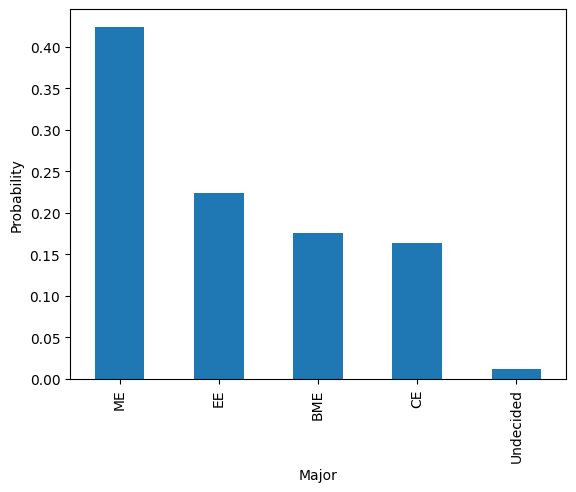

In [46]:
#Use this cell to generate your plot.
df.iloc[:, 0].value_counts(normalize=True).plot(kind="bar", ylabel = "Probability")

Pandas also lets refer to columns by their names, rather than just their indices. One issue in our dataset is that the column name is the entire survey question. Let's go ahead and rename columns with simpler titles, and display the data frame again to see that it worked.

In [27]:
df.columns = ["Major","Preferred Activity", "AI Opinion", "AI Usage", "Smartphone Age"]
df

,Major,Preferred Activity,AI Opinion,AI Usage,Smartphone Age
0,BME,Pen-and-paper math,"Neutral, and I use it when it helps me.",I use AI to explain concepts and check my answ...,13
1,ME,Pen-and-paper math,I like it and I use it wherever possible.,I use AI to explain concepts and check my answ...,13
2,ME,Pen-and-paper math,"Neutral, and I use it when it helps me.",I only use AI to check my answers.,11
3,ME,Writing reports and making presentations,"Neutral, and I use it when it helps me.",I use AI to explain concepts and check my answ...,13
4,BME,Writing reports and making presentations,"Neutral, and I use it when it helps me.",I use AI to explain concepts and check my answ...,13
...,...,...,...,...,...
160,ME,Pen-and-paper math,"Neutral, and I use it when it helps me.",I only use AI as a tool in case I do not under...,16
161,ME,Pen-and-paper math,I dislike when people use it to outsource basi...,I use AI to explain concepts and check my answ...,11
162,CE,Programming algorithms,"Neutral, and I use it when it helps me.",I use AI to explain concepts and check my answ...,11
163,ME,Pen-and-paper math,I dislike it and I avoid it if I can.,I don't use AI at all.,13


Note that you can now call the column by `df["Major"]`, which is more readable than `df.iloc[:,0]`. (Note calling columns by their name is sensitive to capitalization.)

In [28]:
df["Major"]

0      BME
1       ME
2       ME
3       ME
4      BME
      ... 
160     ME
161     ME
162     CE
163     ME
164     ME
Name: Major, Length: 165, dtype: str

We can make our dataframe a bit more readable by paraphrasing some of the possible answers. For example, it will be more readable to change "Pen-and-paper math" to "math". We can do this with the `replace` command, as shown below.

In [29]:
df.replace("Pen-and-paper math", "math", inplace = True)
df.replace("Writing reports and making presentations", "writing", inplace = True)
df.replace("Programming algorithms", "coding", inplace = True)
df.replace("Collecting data (in a \"wet lab\" or other setting)", "data collection", inplace = True)
df

,Major,Preferred Activity,AI Opinion,AI Usage,Smartphone Age
0,BME,math,"Neutral, and I use it when it helps me.",I use AI to explain concepts and check my answ...,13
1,ME,math,I like it and I use it wherever possible.,I use AI to explain concepts and check my answ...,13
2,ME,math,"Neutral, and I use it when it helps me.",I only use AI to check my answers.,11
3,ME,writing,"Neutral, and I use it when it helps me.",I use AI to explain concepts and check my answ...,13
4,BME,writing,"Neutral, and I use it when it helps me.",I use AI to explain concepts and check my answ...,13
...,...,...,...,...,...
160,ME,math,"Neutral, and I use it when it helps me.",I only use AI as a tool in case I do not under...,16
161,ME,math,I dislike when people use it to outsource basi...,I use AI to explain concepts and check my answ...,11
162,CE,coding,"Neutral, and I use it when it helps me.",I use AI to explain concepts and check my answ...,11
163,ME,math,I dislike it and I avoid it if I can.,I don't use AI at all.,13


---
#### L2.4 How many respondents are both BME majors and prefer math?

#### Answer: 11
---
Recall that you can use `value_counts()` on two (or more) columns at once. You can select multiple columns by their indices with `iloc` or by their column names with `loc`. For example, `df.iloc[:,[2,3]]` refers to the 2nd and 3rd columns and `df.loc[:,["Preferred Activity","AI Opinion"]]` has the same effect. Note that the initial colon `:` means "all of the rows."

In [47]:
#Use this cell for your computations.
df.iloc[:, [0, 1]].value_counts()["BME", "math"]

11

We could make a histogram of all these configurations, but it is difficult to get insight, especially since the x-axis is not sorted in a useful way. (Feel free to try this by adding `.plot(kind = "bar")` after your `value_counts()` command.)
Instead, it is more useful to try to inspect this data using crosstabs and conditional probability, as we did above.

---
#### L2.5 Generate a "crosstab" table with "Preferred Activity" along the rows and "Major" along the columns, normalized by columns.
---

In [49]:
#Use this cell to generate your crosstab.

pd.crosstab(df["Preferred Activity"], df["Major"], normalize = True)

Major,BME,CE,EE,ME,Undecided
Preferred Activity,,,,,
coding,0.042424,0.072727,0.060606,0.042424,0.006061
data collection,0.060606,0.018182,0.006061,0.060606,0.000000
math,0.066667,0.060606,0.139394,0.284848,0.006061
writing,0.006061,0.012121,0.018182,0.036364,0.000000


---
#### L2.6 Create a histogram for this crosstab. Comment below on whether any specific majors strongly prefer certain activities, compared to other majors.  

#### Comment:
---

<Axes: xlabel='Preferred Activity', ylabel='Probability'>

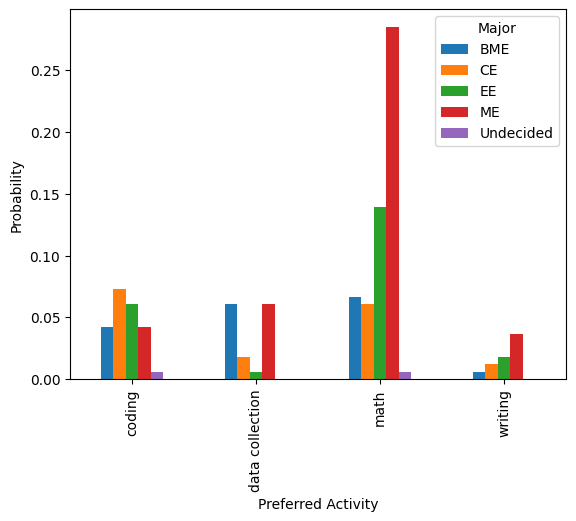

In [50]:
#Use this cell to generate your histogram.


pd.crosstab(df["Preferred Activity"], df["Major"], normalize = True).plot(kind = "bar", ylabel = "Probability")

Finally, let's preview some of the functionality of pandas for generating estimates of probability mass functions (PMFs). We can use the "At what age did you get your first smartphone?" question since the answers are integer-valued. There is one data processing issue to deal with first. The age values in the CSV file are actually strings, not integers, which will make them hard to sort. Let's convert them to integers.

<Axes: title={'center': 'Age of Respondent at First Smartphone'}, xlabel='Age in Years', ylabel='Probability'>

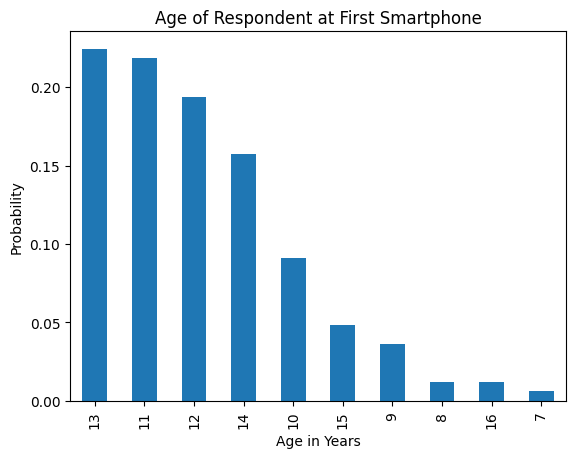

In [33]:
smartphone = df["Smartphone Age"]
smartphone = pd.to_numeric(smartphone)
#Note below I can encapsulate my command in parentheses to break it up over multiple lines.
(smartphone
 .value_counts(normalize = True)
 .plot(kind="bar",xlabel = "Age in Years", ylabel = "Probability", title = "Age of Respondent at First Smartphone")
)

Notice that the plot is sorted by descending probability values, rather than by the x-axis, which is what we would find more intuitive and readable. To fix this, I can just apply `sort_index()` right after `value_counts()`.

<Axes: title={'center': 'Age of Respondent at First Smartphone'}, xlabel='Age in Years', ylabel='Probability'>

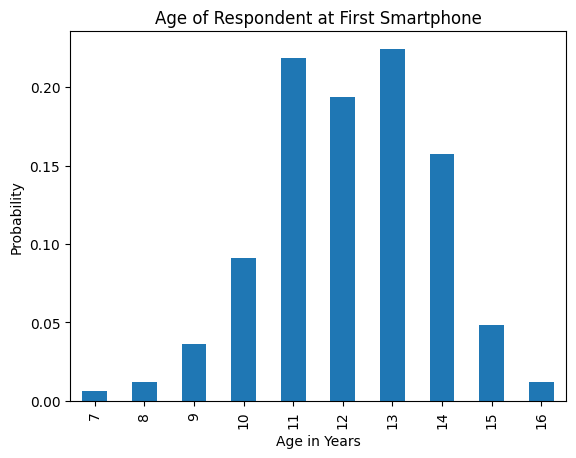

In [34]:
(smartphone
 .value_counts(normalize = True)
 .sort_index()
 .plot(kind="bar",xlabel = "Age in Years", ylabel = "Probability", title = "Age of Respondent at First Smartphone")
)

---
#### L2.7 Below, in your own words, provide a rough description of this distribution. Where is it centered? Is it roughly symmetric?

#### Comment: it is roughly symmetric, centered at around 12-13 with more outliers in the younger part
---

Finally, let's get an estimate of the cumulative distribution function. As an example, say I create a simple probability mass function (PMF)   

In [35]:
pmftest = pd.Series([0.3, 0.2, 0.4, 0.1])
pmftest

0    0.3
1    0.2
2    0.4
3    0.1
dtype: float64

How do I find the sum of the probability for a given value *and* all preceding values? I can simply use the `cumsum()` command, as shown below. For example, note that 0.3 + 0.2 = 0.5, and 0.3 + 0.2 + 0.4 = 0.9.

In [36]:
pmftest.cumsum()

0    0.3
1    0.5
2    0.9
3    1.0
dtype: float64

---
#### L2.8 Estimate the probability that an EK381 student got their first smartphone at age 12 or less.

#### Answer:
---
Hint: Start by counting the values (with normalization on), and then sorting them. (This is done above as part of the histogram generation.) Now, use the cumulative sum.

<Axes: title={'center': 'Cumulative Distribution of Smartphone Age'}, xlabel='Age in Years', ylabel='Cumulative Probability'>

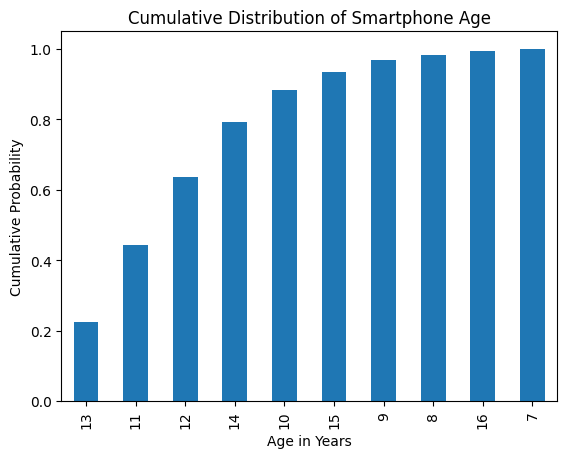

In [52]:
#Use this cell to generate your cumulative distribution.

smartphone.value_counts(normalize=True).cumsum().plot(kind="bar", ylabel = "Cumulative Probability", xlabel = "Age in Years", title = "Cumulative Distribution of Smartphone Age")